In [1]:
# Caution: polluting namespace for convenience
from seaborn import *
from pylab   import *

# LIF and numerical integration lab

This notebook shows some possible solutions to the exercises in the LIF / numerical integration lab. 
These questions are open ended, so expect some variations depending on individual interpretations and style. 

## 1: Forward Euler

The instructions said not to worry about the upward deflection in the spike, but we've included it here just for fun. 

Forward Euler is has second-order error for each step, and first-order global error. It's quick and easy to write and understand, but not especially accurate. You do see forward *exponential* Euler still used to integrate LIF models (or models that are well-approximated as something like LIF for the chosen $\Delta_t$), but forward Euler itself is quite biased and its use is generally frowned upon. 

For compactness, the `simulate_LIF` function below contains code for all 3 questions. It's also fine if you copied/modified a function or iPython notebook cell incrementally when you were working through it. 

<Axes: title={'center': 'LIF spiking simulation'}, xlabel='Time (ms)', ylabel='Membrane\nVoltage (mV)'>

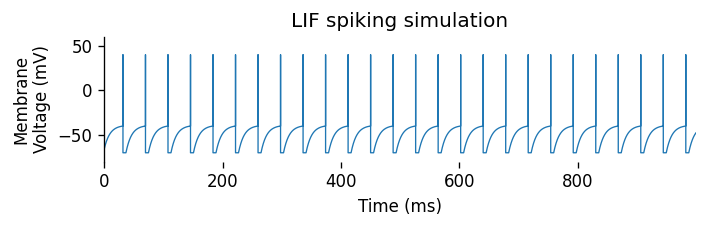

In [2]:
def simulate_LIF(
    dt = 1,    # ms Time steps
    T  = 1000, # ms Total time to simulate
    V0 = None, # mv Initial voltage
    Rm =  10,  # MΩ membrane resistance
    Cm =   1,  # nF membrane capacitance
    El = -70,  # mV leak reversal (resting) voltage
    Vr = -70,  # mV reset voltage
    Vt = -40,  # mV threshold voltage
    Vs =  40,  # mV Positive depolarization value for spikes
    I  = 3.1,  # nA externally applied current
    τref = 5,  # ms absolute refractory period
    var  = 0,  # mV²/ms voltage noise variance
    method = "forward Euler", # or "exponential Euler"
    ):
    τm = Rm*Cm                    # ms membrane time constant
    N  = int(ceil(T/dt))          # Number of steps to simulate
    v  = Vr if V0 is None else V0 # Initial voltage
    tv = [(0,v)]                  # Save time stamps, voltage
    st = []                       # Save spike times
    tref = 0                      # Countdown timer for refractoriness
    α = exp(-dt/τm)               # Constant used for method="exponential Euler"
    noise_scale = sqrt(dt*var)    # Used to scale added noise (if any)
    for t in dt*arange(N):
        if st and st[-1]+τref>=t:
            v = Vr
        else:
            match method:
                case "forward Euler":
                    v = v + ((El - v) + Rm*I)*(dt/τm)
                case "exponential Euler":
                    vinf = El + Rm*I
                    v = α*v + (1-α)*vinf
            if noise_scale>0:
                v += randn()*noise_scale
            if v>=Vt:
                tv+=[(t,v)]
                tv+=[(t,Vs)]
                st+=[t]
                v = Vr
                tref = τref
        tv+=[(t,v)]
    return float32(tv).T, float32(st)

def simpleraxis():
    despine(bottom=True)
    autoscale(tight=True)
    tight_layout()

def my_voltage_plot(t,v,ax=None,**kw):
    if ax is None:
        figure(0,(6,2),120)
        ax = subplot(111)
    plot(t,v,lw=0.8,**kw)
    xlabel("Time (ms)")
    ylabel("Membrane\nVoltage (mV)")
    title("LIF spiking simulation")
    simpleraxis()
    ylim(-80,60)
    return ax

result_fe,st_fe = simulate_LIF()
my_voltage_plot(*result_fe)

## 2: Forward exponential Euler

Forward exponential Euler is the the exact solution to the LIF voltage ODE without the spiking reset. It's still a first order method (with first order global error), but if the system you're integrating is vaguely like a LIF neuron, it has a more appropriate bias (avoids overshoot of $v_\infty$. You may see this in fixed-stepping large-scale simulations of integrate-and-fire type neurons.

This solution isn't *quite* the same thing as the "true" solution to the LIF hybrid equation. The true solution would calculate the exact time within each $\Delta_t$ that the neuron actually crossed threshold. We don't need that level of accuracy for this demo, but analytically solving for when the LIF model spikes, given a constant current, is a standard exam problem. 

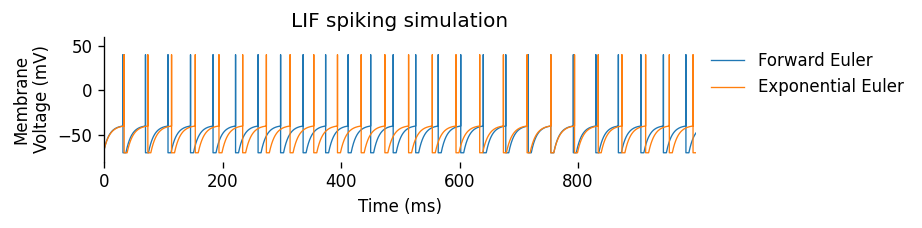

In [3]:
result_ee,st_ee = simulate_LIF(method="exponential Euler")
ax2 = my_voltage_plot(*result_fe,label='Forward Euler')
my_voltage_plot(*result_ee,ax=ax2,label='Exponential Euler')
def right_legend():
    legend(bbox_to_anchor=(1,1),loc='upper left',frameon=False)
right_legend()

### Is the resulting solution the same as forward Euler
No.
### How small do you need to make Δ𝑡 to get the same number of spikes from both approaches?
This might have analytic solution, but the intent here was for the student to play around with it.
$\Delta_t = 0.4$ led to the same number of spikes for me. 

In [4]:
dt = 0.4
result_fe,st_fe = simulate_LIF(dt=dt)
result_ee,st_ee = simulate_LIF(dt=dt,method="exponential Euler")
print(len(st_fe),'=?=',len(st_ee))

25 =?= 25


## 3: Euler-Maruyama

<Axes: title={'center': 'LIF spiking simulation'}, xlabel='Time (ms)', ylabel='Membrane\nVoltage (mV)'>

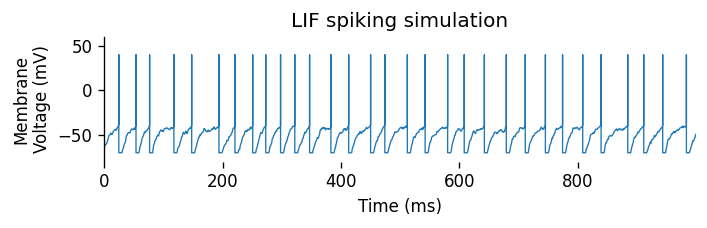

In [5]:
result_em,st_em = simulate_LIF(var=1)
my_voltage_plot(*result_em)

### Does noise change the the neuron’s response to various steady currents?

This was open ended, but one thing you might have noticed is that added noise blurs out the hard firing threshold.

In [12]:
def sweep_frequency_as_function_of_current(II,var,T=10000):
    ff = []
    for I in II:
        st = simulate_LIF(I=I,T=T,var=var)[1]
        f = 1000/mean(diff(st)) if len(st)>10 else 0
        ff.append(f)
    return float32(ff)

noise_var = 10
I0 = 3 # Minimum current (threshold) where cell starts spiking
II = linspace(0,8*I0,101)
ff_nonoise = sweep_frequency_as_function_of_current(II,0 )
ff_noise   = sweep_frequency_as_function_of_current(II,noise_var)

Text(3, 143.52870178222656, '$I_0=3$')

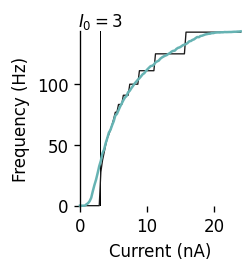

In [11]:
figure(0,(2,2),120)

axvline(rheobase,color='k',lw=.6)
plot(II,ff_nonoise,color=(.1,.1,.1),label='$\\sigma^2=0$',clip_on=False,lw=.8)
plot(II,ff_noise,color=(.4,.7,.7),label='$\\sigma^2=%s$'%noise_var,clip_on=False)
simpleraxis()
xlabel("Current (nA)")
ylabel("Frequency (Hz)")
text(rheobase, ylim()[1], "$I_0=%s$"%rheobase, va='bottom', ha='center')